# V1 Analysis: Does the Size of a Team's Largest Contract Predict Wins?

**Goal:** For each NBA team, find their largest contract (by AAV), then measure whether win rate improved after that contract started — and whether bigger contracts predict bigger improvements.

**The two questions we answer:**
- Do teams win more *after* signing a max contract than *before*?
- Does a *larger* contract predict a *larger* improvement in wins?

---
## Block 1 — Imports and Settings

- Load all the libraries we need
- **`WINDOW`** is the key setting: change it to `1` or `2` to control how many seasons before/after the contract start year are compared
- All file paths point to the `data/` folder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# ── KEY SETTING ──────────────────────────────────────────────────────
# Change this to 1 or 2 to switch between window sizes
WINDOW = 1   # seasons before AND after the contract start year
# ─────────────────────────────────────────────────────────────────────

DATA_DIR = 'data/'

print(f'Window size set to: {WINDOW} season(s) before and after contract start')

Window size set to: 1 season(s) before and after contract start


---
## Block 2 — Load the Data

- Load the two files we need: contracts and team boxscores
- Print the shape of each so we can confirm they loaded correctly

In [3]:
contracts_raw = pd.read_csv(DATA_DIR + 'NBA_Contracts.csv')
boxscore_raw  = pd.read_csv(DATA_DIR + 'nba_team_boxscore.csv')

print('Contracts shape:', contracts_raw.shape)
print('Team boxscore shape:', boxscore_raw.shape)

print('\nContracts columns:', contracts_raw.columns.tolist())
print('\nBoxscore columns:', boxscore_raw.columns.tolist())

Contracts shape: (583, 11)
Team boxscore shape: (14880, 57)

Contracts columns: ['Player', 'Pos', 'Team                     Currently With', 'Age                     At Signing', 'Start', 'End', 'Yrs', 'Value', 'AAV', '2-Year Cash', '3-Year Cash']

Boxscore columns: ['game_id', 'season', 'season_type', 'game_date', 'game_date_time', 'team_id', 'team_uid', 'team_slug', 'team_location', 'team_name', 'team_abbreviation', 'team_display_name', 'team_short_display_name', 'team_color', 'team_alternate_color', 'team_logo', 'team_home_away', 'team_score', 'team_winner', 'assists', 'blocks', 'defensive_rebounds', 'fast_break_points', 'field_goal_pct', 'field_goals_made', 'field_goals_attempted', 'flagrant_fouls', 'fouls', 'free_throw_pct', 'free_throws_made', 'free_throws_attempted', 'largest_lead', 'offensive_rebounds', 'points_in_paint', 'steals', 'team_turnovers', 'technical_fouls', 'three_point_field_goal_pct', 'three_point_field_goals_made', 'three_point_field_goals_attempted', 'total_rebou

---
## Block 3 — Clean the Contracts Data

- The `Team` and `AAV` columns have messy formatting (extra spaces, dollar signs, commas)
- We strip whitespace from the team column and convert `AAV` to a real number
- We also drop coaches (`COA`) since we only care about player contracts

In [12]:
contracts = contracts_raw.copy()

# Clean column names (the team column has extra spaces in the raw file)
contracts.columns = contracts.columns.str.strip()
contracts = contracts.rename(columns={'Team                     Currently With': 'Team'})

# Clean the Team column
contracts['Team'] = contracts['Team'].str.strip().str.split().str[0]


contracts['AAV_clean'] = (
    contracts['AAV']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Drop coaches — we only want player contracts
contracts = contracts[contracts['Pos'] != 'COA'].copy()

print('Cleaned contracts shape:', contracts.shape)
print('\nSample rows:')
contracts[['Player', 'Team', 'Pos', 'Start', 'AAV_clean']].head(8)

Cleaned contracts shape: (582, 12)

Sample rows:


,Player,Team,Pos,Start,AAV_clean
0,Jayson Tatum,BOS,PF,2025,62786682.0
1,Jaylen Brown,BOS,SF,2024,57078728.0
2,Nikola Jokic,DEN,C,2023,55224526.0
3,Shai Gilgeous-Alexander,OKC,PG,2027,67914000.0
4,Evan Mobley,CLE,PF,2025,53817156.0
5,Cade Cunningham,DET,PG,2025,53817156.0
6,Anthony Edwards,MIN,SG,2024,48924624.0
7,Tyrese Haliburton,IND,PG,2024,48924624.0


---
## Block 4 — Find Each Team's Largest Contract (by AAV)

- For each team, keep only the one contract with the highest AAV
- This is our "event" — the signing we'll measure the before/after effect of
- We also filter out contracts starting after 2024, since we need at least one season of post-signing boxscore data (data goes up to 2025)

In [13]:
# For each team, get the row with the highest AAV
idx = contracts.groupby('Team')['AAV_clean'].idxmax()
top_contracts = contracts.loc[idx].copy()

# Drop contracts that start after 2024 — no 'after' data exists yet
top_contracts = top_contracts[top_contracts['Start'] <= 2024].copy()

# Also need enough 'before' data — drop contracts starting before 2021
# (boxscore data starts at 2020, so we need at least one season before)
top_contracts = top_contracts[top_contracts['Start'] >= 2021].copy()

top_contracts = top_contracts.reset_index(drop=True)

print(f'Teams with usable top contracts: {len(top_contracts)}')
print('\nTop contract per team:')
top_contracts[['Team', 'Player', 'Pos', 'Start', 'AAV_clean']].sort_values('AAV_clean', ascending=False)

Teams with usable top contracts: 13

Top contract per team:


,Team,Player,Pos,Start,AAV_clean
3,DEN,Nikola Jokic,C,2023,55224526.0
10,NYK,Karl-Anthony Towns,C,2024,55110496.0
6,LAC,Kawhi Leonard,SF,2024,49835267.0
5,IND,Tyrese Haliburton,PG,2024,48924624.0
8,MIN,Anthony Edwards,SG,2024,48924624.0
4,HOU,Kevin Durant,SF,2022,48554830.0
12,SAC,Domantas Sabonis,PF,2024,46504000.0
2,CHA,LaMelo Ball,PG,2024,40770520.0
7,MEM,Ja Morant,PG,2023,39446090.0
9,NOP,Zion Williamson,PF,2023,39446090.0


---
## Block 5 — Clean the Team Boxscore Data

- Keep only regular season games (`season_type == 2`) so postseason results don't distort win rates
- Each row is one team's performance in one game — we'll aggregate to season win rates in the next block

In [14]:
boxscore = boxscore_raw.copy()

# Keep only regular season games
# season_type: 2 = regular season, 3 = playoffs, 5 = play-in
boxscore = boxscore[boxscore['season_type'] == 2].copy()

# Convert team_winner to integer (True=1, False=0) for easy averaging
boxscore['win'] = boxscore['team_winner'].astype(int)

print('Regular season games shape:', boxscore.shape)
print('Seasons available:', sorted(boxscore['season'].unique()))
print('\nSample rows:')
boxscore[['game_id', 'season', 'team_abbreviation', 'team_score', 'opponent_team_score', 'win']].head(6)

Regular season games shape: (13824, 58)
Seasons available: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Sample rows:


,game_id,season,team_abbreviation,team_score,opponent_team_score,win
168,401224790,2020,PHI,134,96,1
169,401224790,2020,HOU,96,134,0
170,401224792,2020,OKC,103,107,0
171,401224792,2020,LAC,107,103,1
172,401224791,2020,MIA,92,109,0
173,401224791,2020,IND,109,92,1


---
## Block 6 — Calculate Win Rate Per Team Per Season

- Group by team and season, then calculate:
  - Total games played
  - Total wins
  - Win rate (wins / games)
- This gives us one clean row per team per season — the building block for all before/after comparisons

In [15]:
win_rates = (
    boxscore
    .groupby(['team_abbreviation', 'season'])
    .agg(
        games  = ('win', 'count'),
        wins   = ('win', 'sum')
    )
    .reset_index()
)

win_rates['win_rate'] = win_rates['wins'] / win_rates['games']

print('Win rate table shape:', win_rates.shape)
print('\nSample rows:')
win_rates.head(10)

Win rate table shape: (196, 5)

Sample rows:


,team_abbreviation,season,games,wins,win_rate
0,ATL,2020,67,20,0.298507
1,ATL,2021,70,39,0.557143
2,ATL,2022,82,43,0.524390
3,ATL,2023,82,41,0.500000
4,ATL,2024,82,36,0.439024
5,ATL,2025,75,36,0.480000
6,BKN,2020,72,35,0.486111
7,BKN,2021,68,44,0.647059
8,BKN,2022,82,44,0.536585
9,BKN,2023,82,45,0.548780


# Check what abbreviations exist in each file
contract_teams = set(top_contracts['Team'].unique())
boxscore_teams = set(win_rates['team_abbreviation'].unique())

print("In contracts but NOT in boxscore:")
print(contract_teams - boxscore_teams)

print("\nIn boxscore but NOT in contracts:")
print(boxscore_teams - contract_teams)

In [16]:
# Check what abbreviations exist in each file
contract_teams = set(top_contracts['Team'].unique())
boxscore_teams = set(win_rates['team_abbreviation'].unique())

print("In contracts but NOT in boxscore:")
print(contract_teams - boxscore_teams)

print("\nIn boxscore but NOT in contracts:")
print(boxscore_teams - contract_teams)

In contracts but NOT in boxscore:
{'NOP', 'NYK'}

In boxscore but NOT in contracts:
{'DUR', 'LEB', 'NO', 'WORLD', 'CAN', 'SA', 'DAL', 'CHK', 'GS', 'SHQ', 'MIA', 'PHI', 'NY', 'WSH', 'BOS', 'OKC', 'TOR', 'LAL', 'MIL', 'DET', 'KEN', 'EAST', 'UTAH', 'CHI', 'ORL', 'WEST', 'USA', 'PHX', 'GIA', 'CLE'}


---
## Block 7 — Calculate Before/After Win Rate for Each Team

- For each team's top contract, use the `WINDOW` setting from Block 1
- **Before window:** seasons from `(start - WINDOW)` to `(start - 1)`
- **After window:** seasons from `(start)` to `(start + WINDOW - 1)`
- We take the average win rate across those seasons
- Teams without enough data on either side are dropped

In [17]:
results = []

for _, row in top_contracts.iterrows():
    team       = row['Team']
    start_year = row['Start']
    aav        = row['AAV_clean']
    player     = row['Player']

    # Get this team's win rate history
    team_data = win_rates[win_rates['team_abbreviation'] == team].copy()

    # Define the before and after season windows
    before_seasons = list(range(start_year - WINDOW, start_year))
    after_seasons  = list(range(start_year, start_year + WINDOW))

    # Calculate average win rate in each window
    before_data = team_data[team_data['season'].isin(before_seasons)]
    after_data  = team_data[team_data['season'].isin(after_seasons)]

    # Skip teams that don't have data on both sides
    if len(before_data) == 0 or len(after_data) == 0:
        print(f'  Skipping {team} ({player}) — missing before or after data')
        continue

    before_win_rate = before_data['win_rate'].mean()
    after_win_rate  = after_data['win_rate'].mean()
    win_rate_change = after_win_rate - before_win_rate

    results.append({
        'team':             team,
        'player':           player,
        'contract_start':   start_year,
        'aav':              aav,
        'aav_millions':     aav / 1_000_000,
        'before_win_rate':  round(before_win_rate, 4),
        'after_win_rate':   round(after_win_rate, 4),
        'win_rate_change':  round(win_rate_change, 4),
    })

results_df = pd.DataFrame(results)

print(f'Teams included in analysis: {len(results_df)}')
print(f'Window size used: {WINDOW} season(s)')
print('\nFull results table:')
results_df.sort_values('win_rate_change', ascending=False)

  Skipping NOP (Zion Williamson) — missing before or after data
  Skipping NYK (Karl-Anthony Towns) — missing before or after data
Teams included in analysis: 11
Window size used: 1 season(s)

Full results table:


,team,player,contract_start,aav,aav_millions,before_win_rate,after_win_rate,win_rate_change
8,MIN,Anthony Edwards,2024,48924624.0,48.924624,0.5122,0.6829,0.1707
5,IND,Tyrese Haliburton,2024,48924624.0,48.924624,0.4268,0.5663,0.1394
6,LAC,Kawhi Leonard,2024,49835267.0,49.835267,0.5366,0.6220,0.0854
3,DEN,Nikola Jokic,2023,55224526.0,55.224526,0.5854,0.6463,0.0610
4,HOU,Kevin Durant,2022,48554830.0,48.554830,0.2361,0.2439,0.0078
10,SAC,Domantas Sabonis,2024,46504000.0,46.504000,0.5854,0.5610,-0.0244
0,ATL,C.J. McCollum,2024,32000000.0,32.000000,0.5000,0.4390,-0.0610
7,MEM,Ja Morant,2023,39446090.0,39.446090,0.6829,0.6220,-0.0610
2,CHA,LaMelo Ball,2024,40770520.0,40.770520,0.3293,0.2561,-0.0732
1,BKN,Michael Porter Jr.,2022,35859950.0,35.859950,0.6471,0.5366,-0.1105


---
## Block 8 — Statistical Test: Did Teams Win More After the Contract?

- Run a **paired t-test** comparing each team's before vs. after win rate
- This tells us: across all teams, was the *average change* in win rate significantly different from zero?
- A p-value < 0.05 means the change is unlikely to be random chance
- We also print the mean before/after win rates to see the direction of the effect

In [18]:
before = results_df['before_win_rate'].values
after  = results_df['after_win_rate'].values

t_stat, p_value = stats.ttest_rel(before, after)

mean_before = before.mean()
mean_after  = after.mean()
mean_change = results_df['win_rate_change'].mean()

print('─' * 45)
print(f'  Window size:          {WINDOW} season(s)')
print(f'  Teams in test:        {len(results_df)}')
print('─' * 45)
print(f'  Mean win rate BEFORE: {mean_before:.3f}  ({mean_before*82:.1f} wins / 82 games)')
print(f'  Mean win rate AFTER:  {mean_after:.3f}  ({mean_after*82:.1f} wins / 82 games)')
print(f'  Mean change:          {mean_change:+.3f}')
print('─' * 45)
print(f'  Paired t-test:')
print(f'    t-statistic:        {t_stat:.3f}')
print(f'    p-value:            {p_value:.4f}')
print('─' * 45)

if p_value < 0.05:
    direction = 'INCREASE' if mean_change > 0 else 'DECREASE'
    print(f'  Result: Statistically significant {direction} in win rate (p < 0.05)')
else:
    print(f'  Result: No statistically significant change in win rate (p >= 0.05)')

─────────────────────────────────────────────
  Window size:          1 season(s)
  Teams in test:        11
─────────────────────────────────────────────
  Mean win rate BEFORE: 0.495  (40.6 wins / 82 games)
  Mean win rate AFTER:  0.494  (40.5 wins / 82 games)
  Mean change:          -0.001
─────────────────────────────────────────────
  Paired t-test:
    t-statistic:        0.035
    p-value:            0.9727
─────────────────────────────────────────────
  Result: No statistically significant change in win rate (p >= 0.05)


---
## Block 9 — Statistical Test: Does Contract Size Predict Win Rate Change?

- Run a **linear regression**: does AAV (x) predict the change in win rate (y)?
- The **R² value** tells us how much of the variation in win rate change is explained by contract size
- The **slope** tells us: for every extra $1M in AAV, how much does win rate change?
- A p-value < 0.05 means the relationship is statistically significant

In [19]:
x = results_df['aav_millions'].values
y = results_df['win_rate_change'].values

slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)

r_squared = r_value ** 2

print('─' * 50)
print(f'  Window size:          {WINDOW} season(s)')
print(f'  Teams in regression:  {len(results_df)}')
print('─' * 50)
print(f'  Linear regression: AAV → Win Rate Change')
print(f'    Slope:              {slope:.6f}  (win rate change per $1M AAV)')
print(f'    Intercept:          {intercept:.4f}')
print(f'    R²:                 {r_squared:.4f}  ({r_squared*100:.1f}% of variance explained)')
print(f'    p-value:            {p_value_reg:.4f}')
print('─' * 50)

if p_value_reg < 0.05:
    direction = 'positive' if slope > 0 else 'negative'
    print(f'  Result: Statistically significant {direction} relationship (p < 0.05)')
    print(f'          Larger contracts are associated with {"more" if slope > 0 else "fewer"} wins')
else:
    print(f'  Result: No statistically significant relationship between AAV and win rate change (p >= 0.05)')

──────────────────────────────────────────────────
  Window size:          1 season(s)
  Teams in regression:  11
──────────────────────────────────────────────────
  Linear regression: AAV → Win Rate Change
    Slope:              0.010879  (win rate change per $1M AAV)
    Intercept:          -0.4755
    R²:                 0.6475  (64.7% of variance explained)
    p-value:            0.0028
──────────────────────────────────────────────────
  Result: Statistically significant positive relationship (p < 0.05)
          Larger contracts are associated with more wins


---
## Block 10 — Plot 1: Before vs. After Win Rate per Team

- A simple bar chart showing each team's win rate before and after the contract
- Teams are sorted by the size of their improvement (or decline)
- This makes it easy to spot which teams got the biggest benefit — or hurt themselves

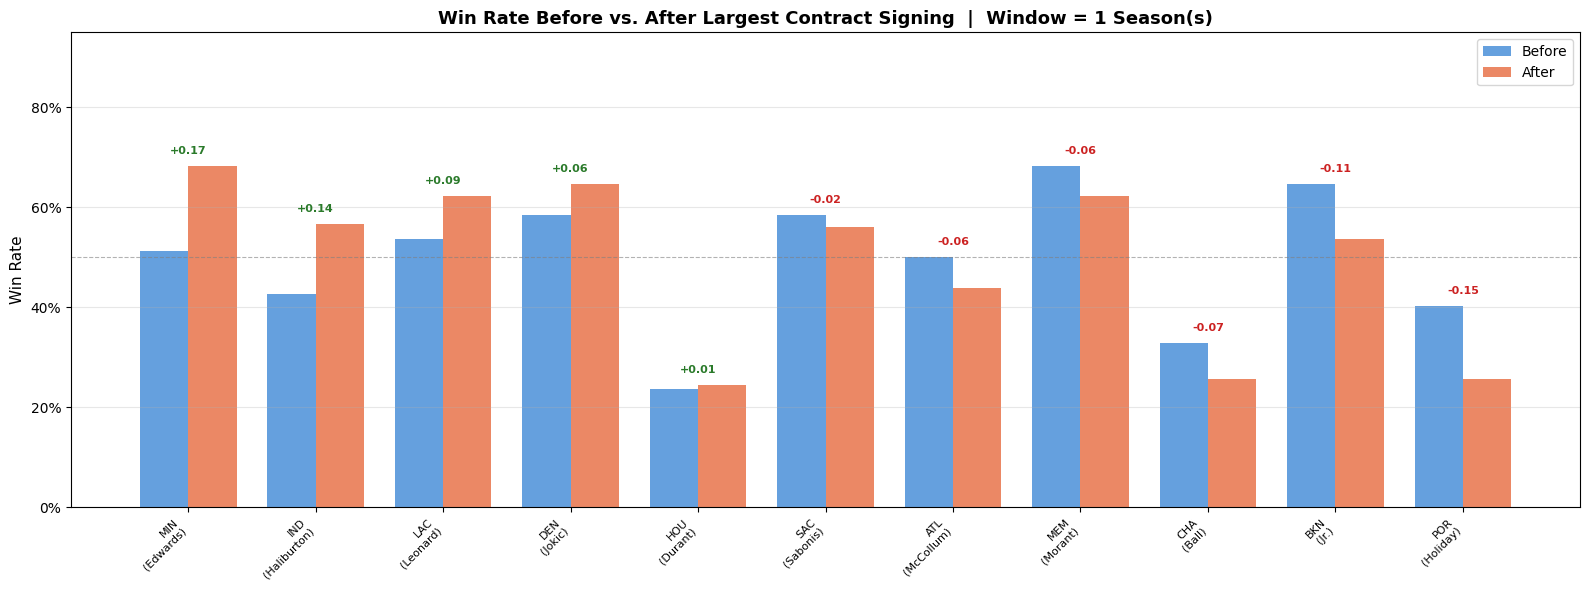

Saved: v1_before_after_win_rate.png


In [20]:
plot_df = results_df.sort_values('win_rate_change', ascending=False).reset_index(drop=True)

x_pos  = np.arange(len(plot_df))
width  = 0.38

fig, ax = plt.subplots(figsize=(16, 6))

bars_before = ax.bar(x_pos - width/2, plot_df['before_win_rate'], width, label='Before', color='#4a90d9', alpha=0.85)
bars_after  = ax.bar(x_pos + width/2, plot_df['after_win_rate'],  width, label='After',  color='#e8734a', alpha=0.85)

# Label the change on top of each pair
for i, (_, row) in enumerate(plot_df.iterrows()):
    change = row['win_rate_change']
    color  = '#2a7a2a' if change >= 0 else '#cc2222'
    label  = f'{change:+.2f}'
    ax.text(i, max(row['before_win_rate'], row['after_win_rate']) + 0.02,
            label, ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)

ax.set_xticks(x_pos)
ax.set_xticklabels(
    [f"{row['team']}\n({row['player'].split()[-1]})" for _, row in plot_df.iterrows()],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Win Rate', fontsize=11)
ax.set_title(f'Win Rate Before vs. After Largest Contract Signing  |  Window = {WINDOW} Season(s)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 0.95)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='.500')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('v1_before_after_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v1_before_after_win_rate.png')

---
## Block 11 — Plot 2: Contract Size vs. Win Rate Change (Scatter + Regression Line)

- Each dot is one team
- X-axis: contract AAV in millions
- Y-axis: how much their win rate changed after the signing
- The regression line shows the overall trend
- Points above the dotted zero line = team improved; below = team got worse

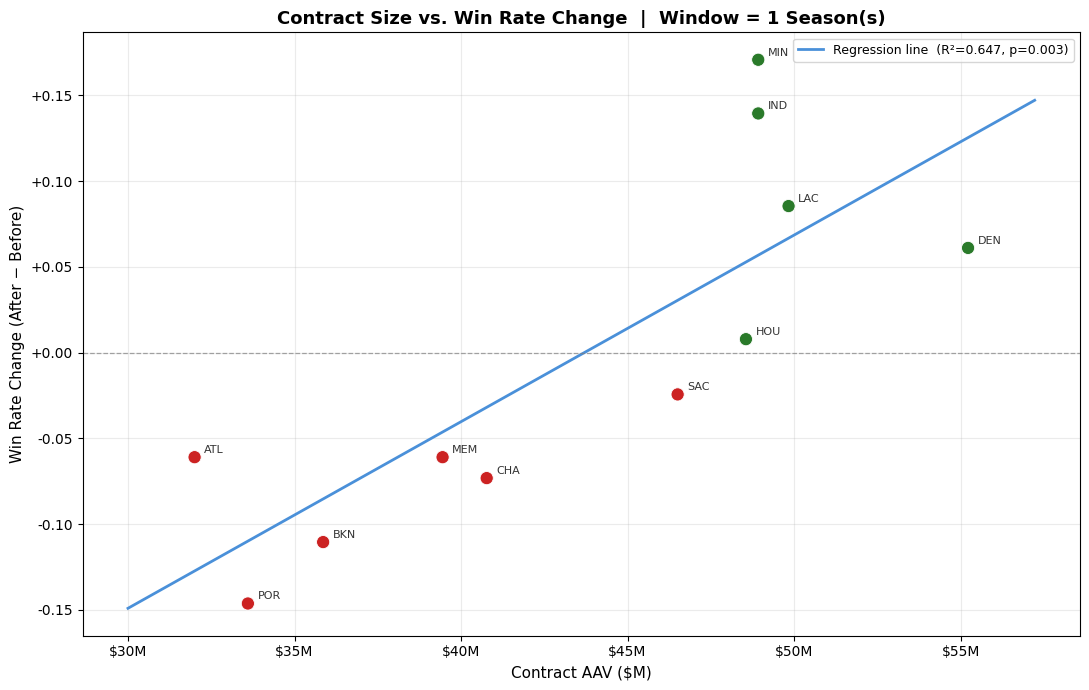

Saved: v1_contract_vs_win_change.png


In [21]:
x = results_df['aav_millions'].values
y = results_df['win_rate_change'].values

slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)
line_x = np.linspace(x.min() - 2, x.max() + 2, 100)
line_y = slope * line_x + intercept

fig, ax = plt.subplots(figsize=(11, 7))

# Color points by positive/negative change
colors = ['#2a7a2a' if v >= 0 else '#cc2222' for v in y]
ax.scatter(x, y, c=colors, s=90, zorder=3, edgecolors='white', linewidths=0.6)

# Label each dot
for i, row in results_df.iterrows():
    ax.annotate(
        f"{row['team']}",
        (row['aav_millions'], row['win_rate_change']),
        textcoords='offset points', xytext=(7, 3),
        fontsize=8, color='#333333'
    )

# Regression line
ax.plot(line_x, line_y, color='#4a90d9', linewidth=2, label=f'Regression line  (R²={r_value**2:.3f}, p={p_value_reg:.3f})')

# Zero reference line
ax.axhline(0, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)

ax.set_xlabel('Contract AAV ($M)', fontsize=11)
ax.set_ylabel('Win Rate Change (After − Before)', fontsize=11)
ax.set_title(f'Contract Size vs. Win Rate Change  |  Window = {WINDOW} Season(s)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.2f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('v1_contract_vs_win_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v1_contract_vs_win_change.png')

---
## Block 12 — Summary Table

- A clean printout of every team, their contract, and the key numbers
- Sorted by win rate change so you can immediately see who improved most and who didn't
- This is useful to have on hand when interpreting the statistical results above

In [22]:
summary = results_df[['team', 'player', 'contract_start', 'aav_millions', 'before_win_rate', 'after_win_rate', 'win_rate_change']].copy()
summary = summary.sort_values('win_rate_change', ascending=False).reset_index(drop=True)

summary.columns = ['Team', 'Player', 'Contract Start', 'AAV ($M)', 'Win Rate Before', 'Win Rate After', 'Change']
summary['AAV ($M)']        = summary['AAV ($M)'].map('${:.1f}M'.format)
summary['Win Rate Before'] = summary['Win Rate Before'].map('{:.1%}'.format)
summary['Win Rate After']  = summary['Win Rate After'].map('{:.1%}'.format)
summary['Change']          = summary['Change'].map('{:+.3f}'.format)

print(f'V1 Summary  |  Window = {WINDOW} season(s)')
print('=' * 80)
print(summary.to_string(index=False))
print('=' * 80)
print(f'\nTeams that IMPROVED: {(results_df["win_rate_change"] > 0).sum()}')
print(f'Teams that DECLINED: {(results_df["win_rate_change"] < 0).sum()}')
print(f'Average change:      {results_df["win_rate_change"].mean():+.3f}')

V1 Summary  |  Window = 1 season(s)
Team             Player  Contract Start AAV ($M) Win Rate Before Win Rate After Change
 MIN    Anthony Edwards            2024   $48.9M           51.2%          68.3% +0.171
 IND  Tyrese Haliburton            2024   $48.9M           42.7%          56.6% +0.139
 LAC      Kawhi Leonard            2024   $49.8M           53.7%          62.2% +0.085
 DEN       Nikola Jokic            2023   $55.2M           58.5%          64.6% +0.061
 HOU       Kevin Durant            2022   $48.6M           23.6%          24.4% +0.008
 SAC   Domantas Sabonis            2024   $46.5M           58.5%          56.1% -0.024
 ATL      C.J. McCollum            2024   $32.0M           50.0%          43.9% -0.061
 MEM          Ja Morant            2023   $39.4M           68.3%          62.2% -0.061
 CHA        LaMelo Ball            2024   $40.8M           32.9%          25.6% -0.073
 BKN Michael Porter Jr.            2022   $35.9M           64.7%          53.7% -0.111
 POR   